In [5]:
!pip install matplotlib pandas numpy scikit-learn

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
%matplotlib inline

In [9]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [10]:
X

array([[  5.19491026,   5.61306388],
       [  3.25316412,  -2.00310524],
       [  4.94220237,   5.61576333],
       ...,
       [ -0.60467166, -10.15688389],
       [ -0.87885307,  -9.898571  ],
       [ -1.91821844, -10.57449494]], shape=(1000, 2))

In [11]:
y

array([2, 1, 2, 2, 2, 2, 1, 1, 1, 0, 1, 2, 0, 2, 0, 2, 1, 2, 2, 1, 0, 1,
       0, 0, 2, 0, 0, 1, 0, 2, 1, 2, 0, 1, 0, 2, 2, 0, 0, 0, 2, 0, 1, 1,
       2, 0, 1, 1, 0, 0, 0, 2, 2, 1, 2, 2, 1, 0, 2, 0, 1, 2, 1, 2, 0, 1,
       1, 2, 1, 2, 0, 2, 0, 1, 1, 1, 0, 2, 2, 0, 2, 0, 2, 0, 0, 2, 0, 1,
       0, 2, 0, 2, 0, 0, 2, 0, 2, 1, 0, 2, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2,
       0, 0, 2, 0, 1, 1, 2, 1, 2, 0, 1, 0, 0, 2, 1, 0, 1, 0, 1, 2, 1, 1,
       1, 0, 1, 0, 1, 1, 2, 2, 2, 0, 0, 2, 1, 0, 2, 1, 0, 1, 2, 1, 2, 2,
       0, 2, 1, 0, 1, 1, 1, 2, 1, 0, 1, 1, 2, 0, 0, 2, 2, 1, 0, 1, 2, 0,
       0, 2, 2, 1, 1, 0, 0, 1, 2, 2, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 0, 2,
       2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 1, 2, 1, 1, 2, 1, 0, 0, 1, 2,
       0, 0, 1, 2, 1, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 0, 2, 0, 0, 2, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 2, 1, 1, 2, 1, 2, 2, 2, 0, 1, 1, 0,
       2, 1, 0, 0, 0, 2, 0, 0, 1, 1, 2, 1, 2, 0, 1, 1, 0, 2, 0, 1, 1, 1,
       1, 2, 0, 0, 1, 2, 0, 0, 1, 2, 1, 0, 0, 0, 1,

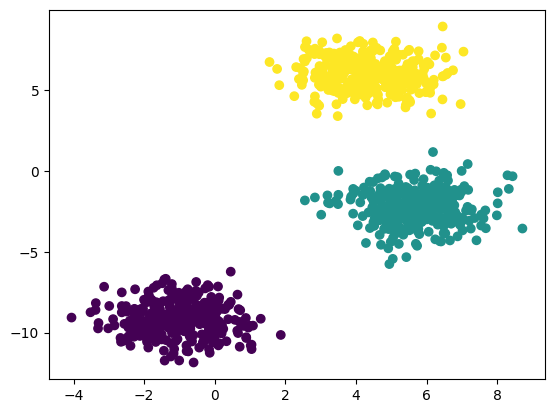

In [12]:
plt.scatter(X[:,0],X[:,1],c=y)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=30)

In [15]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.cluster import KMeans

E-lbow method to select K value

In [18]:
wcss=[]
for k in range(1,11):
    Kmeans = KMeans(n_clusters=k,init='k-means++')
    Kmeans.fit(X_train_scaled)
    wcss.append(Kmeans.inertia_)

In [19]:
wcss

[1339.9999999999998,
 294.9563356518314,
 88.90798828382104,
 74.1389484100767,
 58.973921158753,
 44.03633690741555,
 39.941074359008454,
 35.49285058449581,
 31.13636632567877,
 28.81934829925102]

Plotting Elbow curve

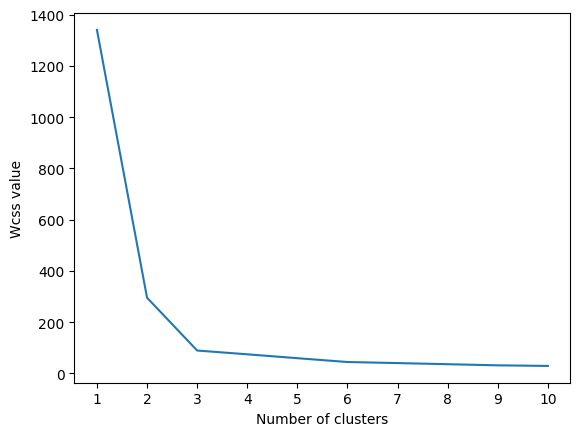

In [20]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("Wcss value")
plt.show()

In [32]:
Kmeans = KMeans(n_clusters = 3,init='k-means++')

In [33]:
Kmeans.fit(X_train_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [34]:
y_pred = Kmeans.predict(X_test_scaled)

In [35]:
y_pred

array([1, 1, 1, 2, 0, 0, 1, 0, 2, 0, 1, 1, 2, 2, 2, 1, 1, 1, 2, 1, 1, 2,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 2, 0, 0, 0, 1, 2, 1, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 2, 1, 1, 1, 0, 2, 0, 2, 1, 2, 1, 0, 2, 2, 1, 2, 1,
       0, 2, 2, 2, 1, 0, 1, 0, 1, 0, 2, 2, 2, 2, 1, 1, 2, 2, 2, 0, 1, 2,
       1, 2, 2, 0, 1, 0, 1, 1, 2, 0, 0, 1, 1, 1, 0, 2, 0, 2, 2, 0, 0, 2,
       2, 0, 0, 2, 2, 0, 0, 2, 2, 1, 0, 0, 0, 2, 2, 1, 1, 2, 1, 1, 2, 2,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 2, 0, 1, 0, 0, 2, 2, 2, 0, 2,
       1, 0, 1, 1, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1, 1,
       2, 2, 2, 1, 2, 2, 2, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 2, 2, 0, 0,
       2, 1, 1, 1, 0, 1, 0, 1, 2, 0, 0, 1, 2, 0, 0, 1, 2, 0, 0, 0, 0, 2,
       2, 2, 1, 2, 0, 1, 2, 0, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 0, 1, 0, 2,
       2, 0, 2, 2, 2, 1, 2, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 2, 2, 1, 1, 0,
       0, 0, 0, 2, 1, 0, 2, 1, 2, 1, 2, 2, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 2,

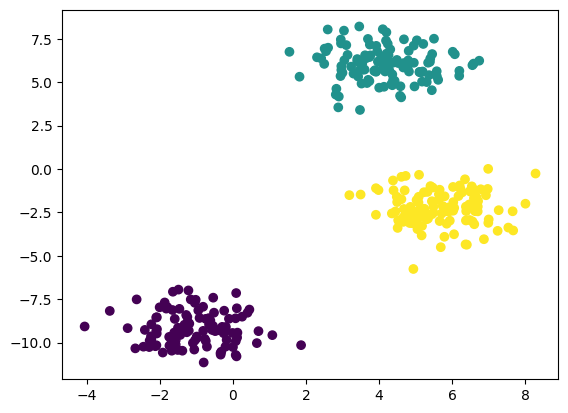

In [36]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

Validating the k value by use knee Locator 

In [37]:
!pip install Kneed

In [40]:

from kneed import KneeLocator

print("Kneed imported successfully!")

Kneed imported successfully!


In [41]:
k1=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [42]:
k1.elbow

np.int64(3)

In [43]:
from sklearn.metrics import silhouette_score

In [52]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [53]:
silhouette_coefficients

[0.710883214050787,
 0.7299026009072039,
 0.5905184759389696,
 0.4966512781502763,
 0.41431244142830437,
 0.46678049795580007,
 0.3864205848293982,
 0.37486236146808166,
 0.3597382438171503]

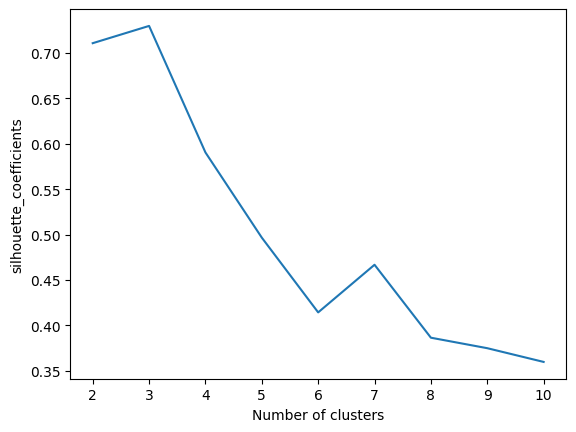

In [54]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("silhouette_coefficients")
plt.show()